In [2]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Processed Dataset
bundle = joblib.load("../backend/models/cancer/cancer_data_bundle.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Success!")
print(f"X_train size: {X_train.shape}, X_test size: {X_test.shape}")

Success!
X_train size: (455, 10), X_test size: (114, 10)


In [3]:
svm_model = SVC(
    kernel="rbf",
    gamma="scale",
    C=1,
    degree=4,
    random_state=42,
    probability=True,
)

In [4]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (K=5) Validation Scores:", cv_scores)
print("Average CV Validation: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (K=5) Validation Scores: [0.97802198 0.97802198 0.94505495 0.93406593 0.98901099]
Average CV Validation: 0.9648 (+/- 0.0426)


/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-p

In [5]:
# Training the Model
svm_model.fit(X_train, y_train)
print("\nModel is trained!")


Model is trained!


/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [6]:
# Train Set Performance (For Overfitting)
y_train_pred = svm_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Set Performance
y_test_pred = svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SET PERFORMANCE          
Train Accuracy: 0.9736

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       285
           1       0.98      0.95      0.96       170

    accuracy                           0.97       455
   macro avg       0.98      0.97      0.97       455
weighted avg       0.97      0.97      0.97       455

          TEST SET PERFORMANCE           
Test Accuracy: 0.9649

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [7]:
# Saving the Model
joblib.dump(svm_model, "../backend/models/cancer/svm_model.pkl")
print("Trained model is successfully saved!")

Trained model is successfully saved!


--- SVM (RBF) Feature Importance Scores ---
               Feature  Importance
0          radius_mean    0.189474
1  radius_growth_ratio    0.061404
6         texture_mean    0.036842
5     smoothness_worst    0.020175
4    concave points_se    0.012281
3     compactness_mean    0.012281
7       symmetry_worst    0.010526
2            radius_se    0.007895
8      smoothness_mean    0.004386
9       compactness_se    0.002632


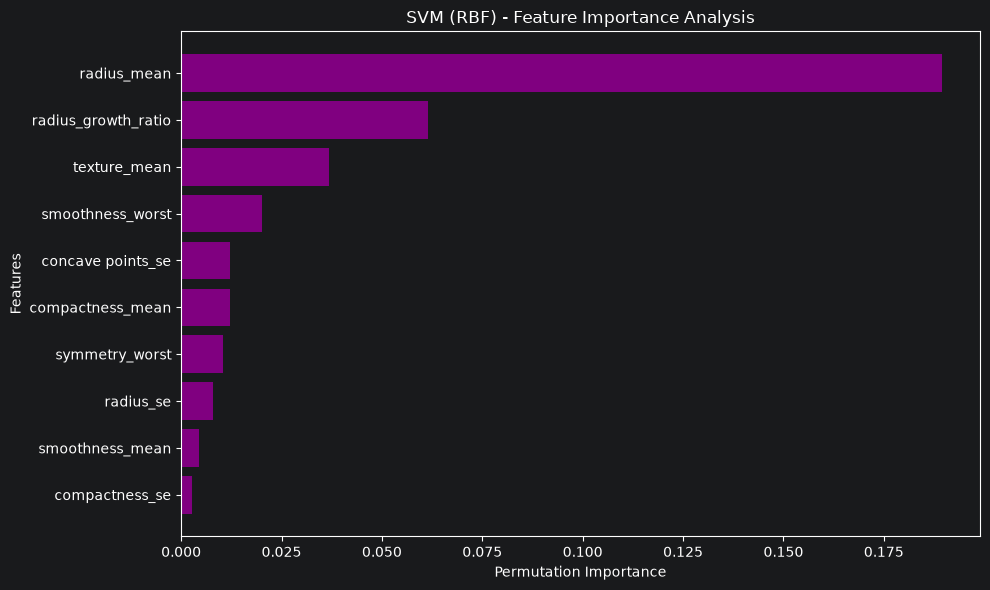

In [8]:
# 1. Permutation Importance Calculation
result = permutation_importance(
    svm_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

importances = result.importances_mean
feature_names = bundle["selected_features"]

# 2. Convert to DataFrame and List
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- SVM (RBF) Feature Importance Scores ---")
print(feature_imp_df)

# 3. Virtualization
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="purple"
)
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("SVM (RBF) - Feature Importance Analysis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# 1. Read the original raw CSV file directly
df = pd.read_csv("../datasets/cancer_data.csv")

# 2. Split into X and y
X = df.drop(
    ["id","diagnosis","Unnamed: 32"], axis=1
)
y = df["diagnosis"]

# 3. Split into Train-Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Model Train with Raw Data
svm_raw_model = SVC(
    kernel="rbf",
    gamma="scale",
    C=1,
    degree=4,
    random_state=42,
)
svm_raw_model.fit(X_train_raw, y_train)

# 5. Train Set Performance for Raw Model
y_train_pred_raw = svm_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("      RAW DATA - TRAIN SET PERFORMANCE      ")
print("=" * 40)
print(f"Train Accuracy Rate: {train_accuracy_raw:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 6. Test Set Performance for Raw Model
y_test_pred_raw = svm_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("      RAW DATA - TEST SET PERFORMANCE       ")
print("=" * 40)
print(f"Test Accuracy Rate: {test_accuracy_raw:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

      RAW DATA - TRAIN SET PERFORMANCE      
Train Accuracy Rate: 0.9187

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       285
           1       0.97      0.81      0.88       170

    accuracy                           0.92       455
   macro avg       0.93      0.90      0.91       455
weighted avg       0.92      0.92      0.92       455

      RAW DATA - TEST SET PERFORMANCE       
Test Accuracy Rate: 0.9035

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        72
           1       1.00      0.74      0.85        42

    accuracy                           0.90       114
   macro avg       0.93      0.87      0.89       114
weighted avg       0.92      0.90      0.90       114

